Generating Asimov Mock Dataset for 2044 effective lenses...

--- Starting MCMC Inference ---

Running Inference for: PDSPL Only
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 800/800 [04:03<00:00,  3.28it/s]



Running Inference for: PDSPL + CMB
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 800/800 [04:03<00:00,  3.28it/s]



Running Inference for: PDSPL + SNe
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 800/800 [03:53<00:00,  3.42it/s]



Running Inference for: PDSPL + CMB + SNe + BAO
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 800/800 [03:51<00:00,  3.46it/s]


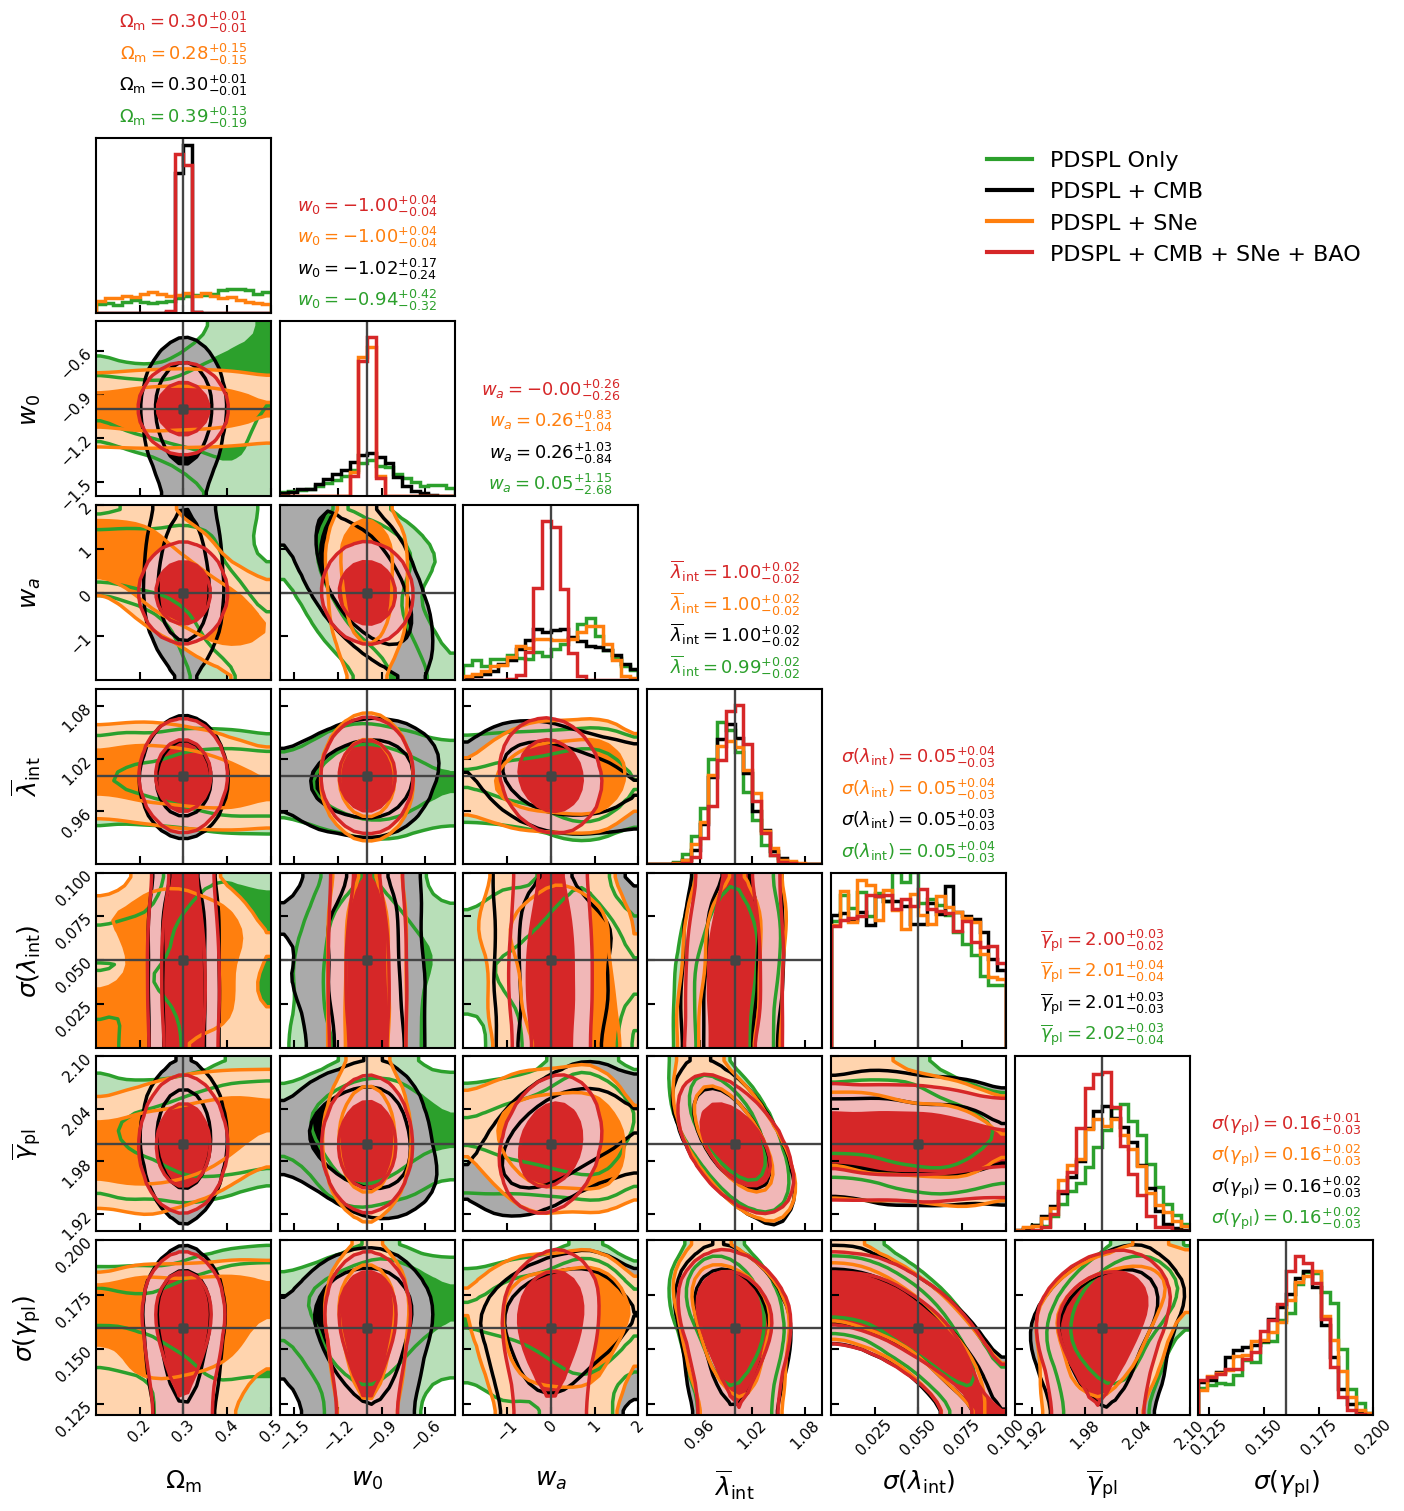

In [1]:
import pickle
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt

# Import your custom modules
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
# Assuming plot_dspl_corner is defined in your utils or you can copy it from your previous notebook
from pdspl_utils.plotting import plot_dspl_corner 

# --- 1. LOAD DATA & TRUTH ---
with open('../../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# --- 2. EXTRACT LSST Y10 EXACTLY ONCE ---
key = 'lsst_y10'
y10_data = pdspl_samples[key]
down_sampling = len(y10_data['pairs_analysis']['pairs_table']) / 2000
down_sampling = int(down_sampling) if down_sampling > 1 else 1
num_samples = int(len(y10_data['pairs_analysis']['pairs_table']) / down_sampling)

pairs_table = y10_data['pairs_analysis']['pairs_table']
pairs_table_with_errors = y10_data['pairs_analysis']['pairs_table_with_errors']
coeffs = y10_data['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs']

print(f"Generating Asimov Mock Dataset for {num_samples} effective lenses...")
kwargs_list = []
random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)

for i in random_indices:
    dissimilarity = pairs_table_with_errors['dissimilarity'][i]
    sigma_beta_intrinsic = np.polyval(coeffs, dissimilarity)
    
    # 1% measurement and line-of-sight error
    sigma_meas_rel = np.sqrt(0.01**2 + 0.01**2)
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=pairs_table["z_D"][i], z1=pairs_table["z_S1"][i], z2=pairs_table["z_S2"][i],
        lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
        gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
        sigma_beta_intrinsic=sigma_beta_intrinsic, 
        sigma_meas_rel=sigma_meas_rel,
        dissimilarity=dissimilarity,
        down_sampling=down_sampling, 
        with_noise=False, # Asimov dataset
        cosmo=cosmo_true, 
        redshift_error_rel=0.03 # 3% photo-z error for LSST
    ))

# Isolate scatter coefficients to freeze them in the MCMC
c0, c1, c2 = 0.0, 0.0, 0.0
if len(coeffs) == 1: c0 = coeffs[0]
elif len(coeffs) == 2: c1, c0 = coeffs
elif len(coeffs) >= 3: c2, c1, c0 = coeffs[-3:]

fixed_params_sc = fixed_params.copy()
fixed_params_sc['beta_c0'] = c0
fixed_params_sc['beta_c1'] = c1
fixed_params_sc['beta_c2'] = c2

# --- 3. DEFINE THE PRIOR SCENARIOS ---
base_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5)
}

scenarios = {
    'PDSPL_Only': {
        'name': 'PDSPL Only',
        'color': '#2ca02c', # Green
        'priors': base_priors.copy()
    },
    'PDSPL_CMB': {
        'name': 'PDSPL + CMB',
        'color': '#000000',
        'priors': {**base_priors, 'om': ('gaussian', 0.30, 0.007)}
    },
    'PDSPL_SNe': {
        'name': 'PDSPL + SNe',
        'color': '#ff7f0e', # Orange/Yellow
        'priors': {**base_priors, 'w0': ('gaussian', -1.0, 0.04)}
    },
    'PDSPL_All': {
        'name': 'PDSPL + CMB + SNe + BAO',
        'color': '#d62728', # Red
        'priors': {**base_priors, 'om': ('gaussian', 0.30, 0.007), 'w0': ('gaussian', -1.0, 0.04), 'wa': ('gaussian', 0.0, 0.3)}
    }
}

# --- 4. RUN THE FORECASTS ---
my_guess = {'om': 0.3, 'w0': -1.0, 'wa': 0.0, 'lambda_int': 1.0, 'lambda_sigma': 0.05, 'gamma_pl': 2.0, 'gamma_sigma': 0.16}
my_spreads = {k: 0.05 for k in my_guess.keys()}

print("\n--- Starting MCMC Inference ---")
for key, sc in scenarios.items():
    print(f"\nRunning Inference for: {sc['name']}")
    
    samples, labels = run_dspl_inference(
        kwargs_list,
        n_walkers=64,
        n_steps=800, 
        n_burn=300,
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=sc['priors'],
        backend_path=None # Keep it in memory for a quick minimal script
    )
    sc['samples'] = samples

# --- 5. PLOT THE RESULTS ---
custom_ranges = [
    (0.1, 0.5),        # om
    (-1.6, -0.4),      # w0
    (-2.0, 2.0),       # wa
    (0.9, 1.1),        # lambda_int
    (0.0, 0.10),       # lambda_sigma
    (1.9, 2.1),        # gamma_pl
    (0.12, 0.20),      # gamma_sigma
]

latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm int})$"
}

custom_colors_dict = {key: sc['color'] for key, sc in scenarios.items()}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params_sc, 
    scenarios_to_plot=list(scenarios.keys()),
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(14, 14),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

plt.show()

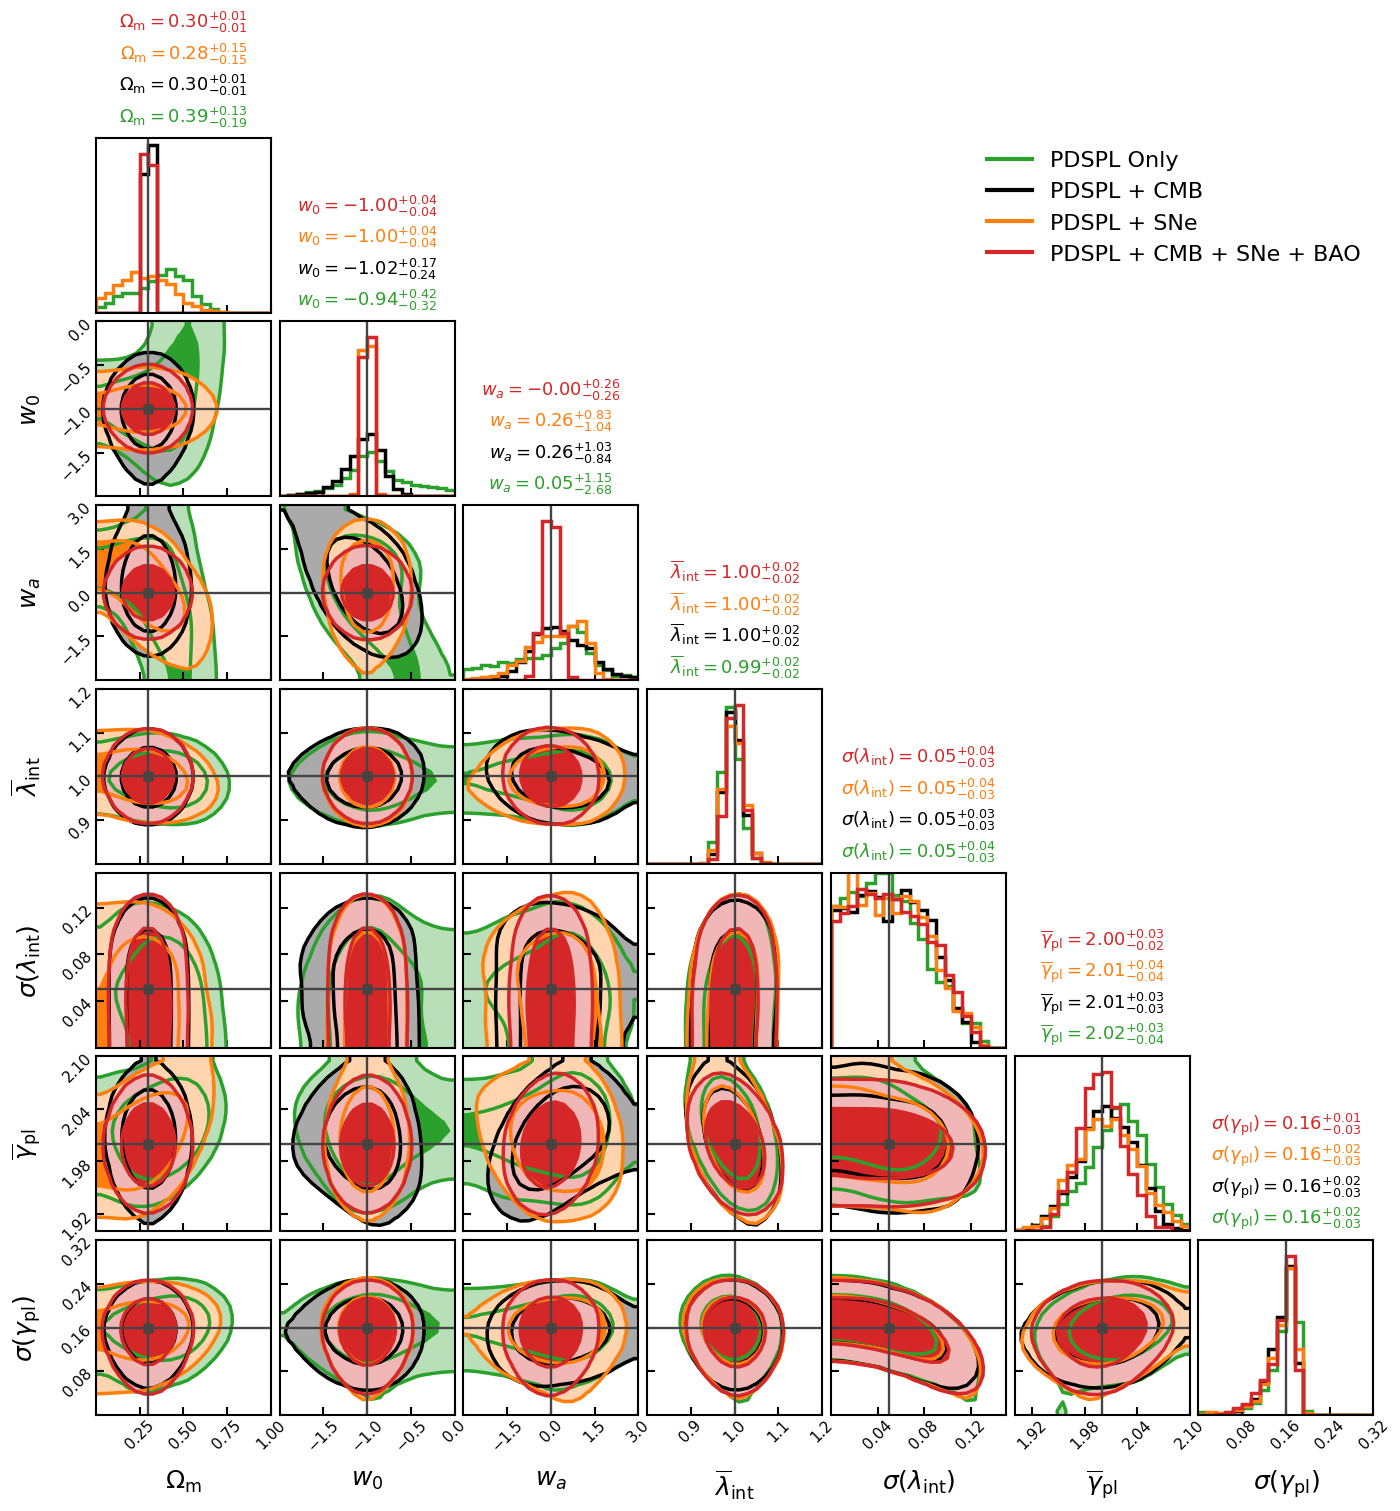

In [3]:
# --- 5. PLOT THE RESULTS ---
custom_ranges = [
    (0, 1),        # om
    (-2.0, 0),      # w0
    (-3.0, 3.0),       # wa
    (0.8, 1.2),        # lambda_int
    (0.0, 0.15),       # lambda_sigma
    (1.9, 2.1),        # gamma_pl
    (0, 0.32),      # gamma_sigma
]

latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm int})$"
}

custom_colors_dict = {key: sc['color'] for key, sc in scenarios.items()}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params_sc, 
    scenarios_to_plot=list(scenarios.keys()),
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(14, 14),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

In [ ]:
# Observation configurations for 1 orbit of WFC3 F475X
WFC3_F475X_band_obs = {
    "exposure_time": 2700.0,  # ~1 HST orbit of science exposure
    "sky_brightness": 25.5,   # Approximate sky brightness for UVIS broad bands
    "magnitude_zero_point": 26.15,  # AB magnitude zero point for WFC3/UVIS F475X
    "num_exposures": 1,
    "seeing": 0.06,  # UVIS PSF FWHM is roughly 0.06"
    "psf_type": "GAUSSIAN",
}

# Camera configurations for the WFC3 UVIS detector
WFC3_UVIS_camera = {
    "read_noise": 3.0,    # Typical read noise for UVIS channel (in electrons)
    "pixel_scale": 0.04,  # Native pixel size for UVIS (in arcseconds)
    "ccd_gain": 1.5,      # Typical gain for UVIS (electrons/ADU)
}